<a href="https://colab.research.google.com/github/heba956/credit-predict/blob/main/credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/drive/MyDrive/credit-score-prediction.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36489 entries, 0 to 36488
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                36489 non-null  int64  
 1   ID                        36489 non-null  object 
 2   Customer_ID               36489 non-null  object 
 3   Month                     36489 non-null  object 
 4   Name                      32868 non-null  object 
 5   Age                       36489 non-null  object 
 6   SSN                       36489 non-null  object 
 7   Occupation                36489 non-null  object 
 8   Annual_Income             36489 non-null  object 
 9   Monthly_Inhand_Salary     31025 non-null  float64
 10  Num_Bank_Accounts         36489 non-null  int64  
 11  Num_Credit_Card           36489 non-null  int64  
 12  Interest_Rate             36489 non-null  int64  
 13  Num_of_Loan               36489 non-null  object 
 14  Type_o

In [4]:
df.describe()

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,36489.000000,31025.000000,36489.000000,36489.000000,36489.000000,36489.000000,35792.000000,36489.000000,36489.000000
mean,18244.000000,4256.244777,16.668804,23.515196,68.924580,21.092220,25.966082,32.312484,1418.088079
std,10533.611323,3218.904902,115.690295,133.339355,450.849969,14.764946,182.299457,5.131819,8384.304978
min,0.000000,332.128333,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,9122.000000,1653.198333,3.000000,4.000000,7.000000,10.000000,3.000000,28.068529,30.907553
50%,18244.000000,3136.363333,6.000000,6.000000,13.000000,18.000000,6.000000,32.334139,70.195078
75%,27366.000000,6034.156667,7.000000,7.000000,20.000000,28.000000,9.000000,36.531987,164.708742
max,36488.000000,15136.696670,1798.000000,1499.000000,5788.000000,67.000000,2594.000000,50.000000,82256.000000


In [5]:
df.head(19)

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529544,High_spent_Small_value_payments,312.4940887,Good
1,1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,...,Good,809.98,31.944960,NaN,No,49.574949,118.2802216,Low_spent_Large_value_payments,284.6291625,Good
2,2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.69952126,Low_spent_Medium_value_payments,331.2098629,Good
3,3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580744,Low_spent_Small_value_payments,223.4513097,Good
4,4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.42015309,High_spent_Medium_value_payments,341.489231,Good
5,5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.43017233,!@9#%8,340.4792118,Good
6,6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674,Low_spent_Small_value_payments,244.5653167,Good
7,7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,...,Good,809.98,23.933795,NaN,No,49.574949,24.78521651,High_spent_Medium_value_payments,358.1241676,Standard
8,8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.2918252,Low_spent_Small_value_payments,470.6906269,Standard
9,9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123783,High_spent_Large_value_payments,484.5912143,Good


In [6]:
df.duplicated().sum()#get number of duplicates

np.int64(0)

In [7]:
df.isna().sum()#get number of missing values

,0
Unnamed: 0,0
ID,0
Customer_ID,0
Month,0
Name,3621
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,5464


In [8]:
df.drop(columns=['Name', 'Unnamed: 0'], inplace=True)#not useful in eda

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36489 entries, 0 to 36488
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        36489 non-null  object 
 1   Customer_ID               36489 non-null  object 
 2   Month                     36489 non-null  object 
 3   Age                       36489 non-null  object 
 4   SSN                       36489 non-null  object 
 5   Occupation                36489 non-null  object 
 6   Annual_Income             36489 non-null  object 
 7   Monthly_Inhand_Salary     31025 non-null  float64
 8   Num_Bank_Accounts         36489 non-null  int64  
 9   Num_Credit_Card           36489 non-null  int64  
 10  Interest_Rate             36489 non-null  int64  
 11  Num_of_Loan               36489 non-null  object 
 12  Type_of_Loan              32345 non-null  object 
 13  Delay_from_due_date       36489 non-null  int64  
 14  Num_of

In [10]:
df['Age'] = df['Age'].astype(str).str.replace('_', '', regex=False)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df.loc[df['Age'] < 0, 'Age'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)
#changed age to an integer to make dealing with it easier

In [11]:
df = df[(df['Age'] <= 110) & (df['Age'] >= 10)] #make sure age is realistic

In [12]:
for col in ['Monthly_Inhand_Salary', 'Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Delay_from_due_date','Num_Credit_Inquiries','Credit_Utilization_Ratio','Total_EMI_per_month']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    min_limit = Q1 - 1.5 * IQR
    max_limit = Q3 + 1.5 * IQR
    outliers = df[(df[col] < min_limit) | (df[col] > max_limit)]
    print(f"{col} Outliers: {len(outliers)}")

Monthly_Inhand_Salary Outliers: 637
Num_Bank_Accounts Outliers: 440
Num_Credit_Card Outliers: 844
Interest_Rate Outliers: 702
Delay_from_due_date Outliers: 1363
Num_Credit_Inquiries Outliers: 563
Credit_Utilization_Ratio Outliers: 2
Total_EMI_per_month Outliers: 2366


In [13]:
for col in ['Monthly_Inhand_Salary','Interest_Rate','Credit_Utilization_Ratio']:
   cap = df[col].quantile(0.99)
   df[col] = df[col].clip(upper=cap)

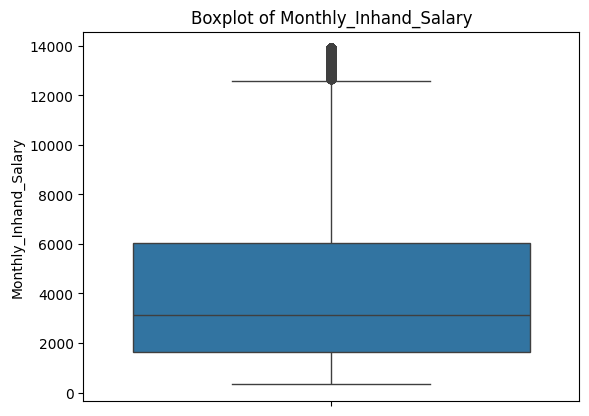

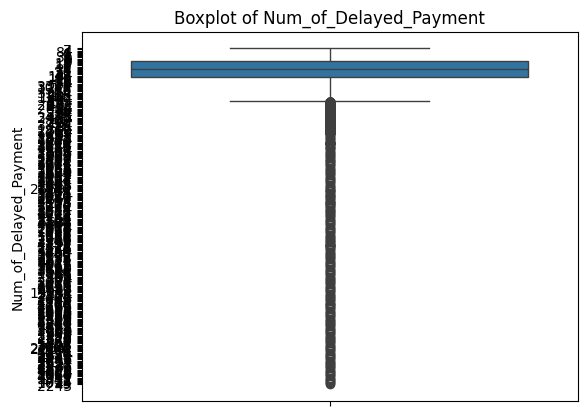

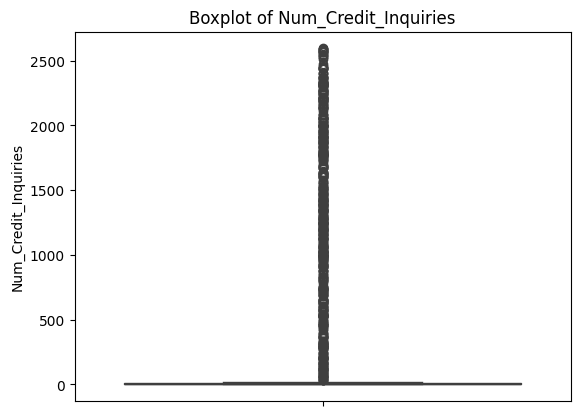

In [14]:
columns_to_check = ['Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']
#fill columns with median if they have nulls and outliers
for col in columns_to_check:
  sns.boxplot(y=df[col]) # Correctly call sns.boxplot with the column data
  plt.title(f'Boxplot of {col}')
  plt.show()

In [15]:
columns_to_fill = ['Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']
#fill columns with median if they have nulls and outliers
for col in columns_to_fill:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35795 entries, 0 to 36488
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        35795 non-null  object 
 1   Customer_ID               35795 non-null  object 
 2   Month                     35795 non-null  object 
 3   Age                       35795 non-null  int64  
 4   SSN                       35795 non-null  object 
 5   Occupation                35795 non-null  object 
 6   Annual_Income             35795 non-null  object 
 7   Monthly_Inhand_Salary     35795 non-null  float64
 8   Num_Bank_Accounts         35795 non-null  int64  
 9   Num_Credit_Card           35795 non-null  int64  
 10  Interest_Rate             35795 non-null  float64
 11  Num_of_Loan               35795 non-null  object 
 12  Type_of_Loan              31731 non-null  object 
 13  Delay_from_due_date       35795 non-null  int64  
 14  Num_of_Dela

In [17]:
df.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0


In [18]:
df[['Amount_invested_monthly', 'Monthly_Balance']]
#check these two columns specifically to see if they can be cast

,Amount_invested_monthly,Monthly_Balance
0,80.41529544,312.4940887
1,118.2802216,284.6291625
2,81.69952126,331.2098629
3,199.4580744,223.4513097
4,41.42015309,341.489231
...,...,...
36484,84.47742348,282.6942663
36485,78.16941102,289.0022787
36486,142.1185156,205.0531742
36487,168.322128,198.8495618


In [19]:
df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
#cast them into floats to make dealing easier

In [20]:
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(df['Amount_invested_monthly'].median())
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(df['Monthly_Balance'].median())
print('Missing values after filling:')
print(df[['Amount_invested_monthly', 'Monthly_Balance']].isna().sum())

Missing values after filling:
Amount_invested_monthly    0
Monthly_Balance            0
dtype: int64


In [21]:
print('Unique values in Type_of_Loan before filling:')
print(df['Type_of_Loan'].value_counts(dropna=False))
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Unknown')
print('\nUnique values in Type_of_Loan after filling:')
print(df['Type_of_Loan'].value_counts(dropna=False))

Unique values in Type_of_Loan before filling:
Type_of_Loan
NaN                                                                                                                                           4064
Credit-Builder Loan                                                                                                                            453
Not Specified                                                                                                                                  441
Personal Loan                                                                                                                                  431
Student Loan                                                                                                                                   407
                                                                                                                                              ... 
Student Loan, Home Equity Loan, Mortgage Loan, Not Specifie

In [22]:
df.dropna(subset=['Credit_Score'], inplace=True)
print('Missing values after dropping rows with missing Credit_Score:')
print(df.isna().sum())

Missing values after dropping rows with missing Credit_Score:
ID                             0
Customer_ID                    0
Month                          0
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                   0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          3310
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
dtype: int64


In [23]:
df.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0


In [24]:
df[['Amount_invested_monthly', 'Monthly_Balance']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 35795 entries, 0 to 36488
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Amount_invested_monthly  35795 non-null  float64
 1   Monthly_Balance          35795 non-null  float64
dtypes: float64(2)
memory usage: 838.9 KB


In [25]:
df[['Amount_invested_monthly', 'Monthly_Balance']].head()

,Amount_invested_monthly,Monthly_Balance
0,80.415295,312.494089
1,118.280222,284.629163
2,81.699521,331.209863
3,199.458074,223.451310
4,41.420153,341.489231


In [26]:
df.describe(include= object)

,ID,Customer_ID,Month,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Payment_Behaviour,Credit_Score
count,35795,35795,35795,35795,35795,35795,35795,35795,35795,35795,35795,32485,35795,35795,35795
unique,35795,4562,8,4563,16,6857,182,2627,3007,4,4873,404,3,7,3
top,0xebce,CUS_0x569b,August,#F%$D@*&8,_______,109945.32,2,Unknown,_,Standard,1170.58,15 Years and 9 Months,Yes,Low_spent_Small_value_payments,Standard
freq,1,8,4488,1957,2472,14,5371,4064,717,12837,16,168,18718,9140,18939


In [27]:
df.drop(columns=['ID', 'SSN'], inplace=True)#not related

In [28]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 35795 entries, 0 to 36488
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               35795 non-null  object 
 1   Month                     35795 non-null  object 
 2   Age                       35795 non-null  int64  
 3   Occupation                35795 non-null  object 
 4   Annual_Income             35795 non-null  object 
 5   Monthly_Inhand_Salary     35795 non-null  float64
 6   Num_Bank_Accounts         35795 non-null  int64  
 7   Num_Credit_Card           35795 non-null  int64  
 8   Interest_Rate             35795 non-null  float64
 9   Num_of_Loan               35795 non-null  object 
 10  Type_of_Loan              35795 non-null  object 
 11  Delay_from_due_date       35795 non-null  int64  
 12  Num_of_Delayed_Payment    35795 non-null  float64
 13  Changed_Credit_Limit      35795 non-null  object 
 14  Num_Credit_

In [29]:
print("Unique values in 'Num_of_Loan' before cleaning:")
print(df['Num_of_Loan'].value_counts(dropna=False))

Unique values in 'Num_of_Loan' before cleaning:
Num_of_Loan
2       5371
4       5220
3       5137
0       3704
1       3306
        ... 
157        1
164        1
1088       1
1236       1
777        1
Name: count, Length: 182, dtype: int64


In [30]:
df['Num_of_Loan'] = df['Num_of_Loan'].astype(str).str.replace('_', '', regex=False)
df['Num_of_Loan'] = pd.to_numeric(df['Num_of_Loan'], errors='coerce')
df['Num_of_Loan'] = df['Num_of_Loan'].fillna(df['Num_of_Loan'].median()).astype(int)

print("Info for 'Num_of_Loan' after cleaning:")
df['Num_of_Loan'].info()
print("\nHead of 'Num_of_Loan' after cleaning:")
df['Num_of_Loan'].head()

Info for 'Num_of_Loan' after cleaning:
<class 'pandas.core.series.Series'>
Index: 35795 entries, 0 to 36488
Series name: Num_of_Loan
Non-Null Count  Dtype
--------------  -----
35795 non-null  int64
dtypes: int64(1)
memory usage: 559.3 KB

Head of 'Num_of_Loan' after cleaning:


,Num_of_Loan
0,4
1,4
2,4
3,4
4,4


In [31]:
df.isna().sum()

,0
Customer_ID,0
Month,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35795 entries, 0 to 36488
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               35795 non-null  object 
 1   Month                     35795 non-null  object 
 2   Age                       35795 non-null  int64  
 3   Occupation                35795 non-null  object 
 4   Annual_Income             35795 non-null  object 
 5   Monthly_Inhand_Salary     35795 non-null  float64
 6   Num_Bank_Accounts         35795 non-null  int64  
 7   Num_Credit_Card           35795 non-null  int64  
 8   Interest_Rate             35795 non-null  float64
 9   Num_of_Loan               35795 non-null  int64  
 10  Type_of_Loan              35795 non-null  object 
 11  Delay_from_due_date       35795 non-null  int64  
 12  Num_of_Delayed_Payment    35795 non-null  float64
 13  Changed_Credit_Limit      35795 non-null  object 
 14  Num_Credit_

In [33]:
df['Credit_History_Age']

,Credit_History_Age
0,22 Years and 1 Months
1,NaN
2,22 Years and 3 Months
3,22 Years and 4 Months
4,22 Years and 5 Months
...,...
36484,10 Years and 6 Months
36485,10 Years and 7 Months
36486,10 Years and 8 Months
36487,10 Years and 9 Months


In [34]:
#split before encoding
x=df.drop(columns=['Credit_Score'])
y=df['Credit_Score']

In [35]:
#Annual_Income,Outstanding_Debt,Changed_Credit_Limit
for col in ['Annual_Income', 'Outstanding_Debt', 'Changed_Credit_Limit']:
    x[col] = pd.to_numeric(x[col].astype(str).str.replace('_',''), errors='coerce')

In [36]:
x['Annual_Income']= x['Annual_Income'].fillna(x['Annual_Income'].mode())

In [37]:
#code to extract the temporal information from text
def parse_credit_history_age(age):
    try:
      years = int(str(age).split('Years')[0].strip())
      months = int(str(age).split('and')[1].split('Months')[0].strip())
      total_months = years * 12 + months
      return total_months
    except:
      return np.nan

In [38]:
#deal with loan types
x['Type_of_Loan'] = x['Type_of_Loan'].fillna('Not Specified')
for loan in ['Personal Loan','Payday Loan','Credit-Builder Loan','Student Loan',
             'Mortgage Loan','Home Equity Loan','Debt Consolidation Loan','Auto Loan']:
    x[f'has_{loan.replace(" ","_")}'] = df['Type_of_Loan'].str.contains(loan).astype(int)
x.drop(columns=['Type_of_Loan'], inplace=True)

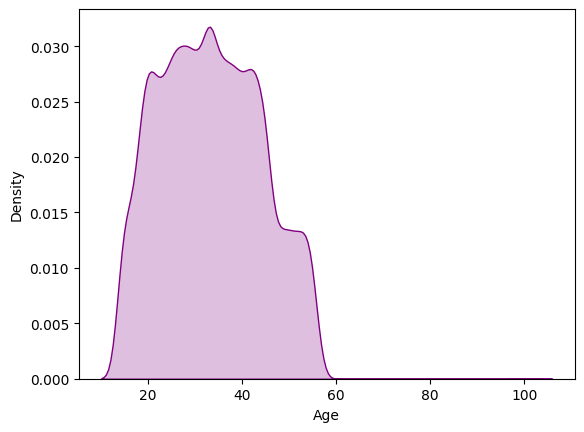

In [39]:
sns.kdeplot(df['Age'], fill=True, color='purple')
plt.show()

<Figure size 1600x900 with 0 Axes>

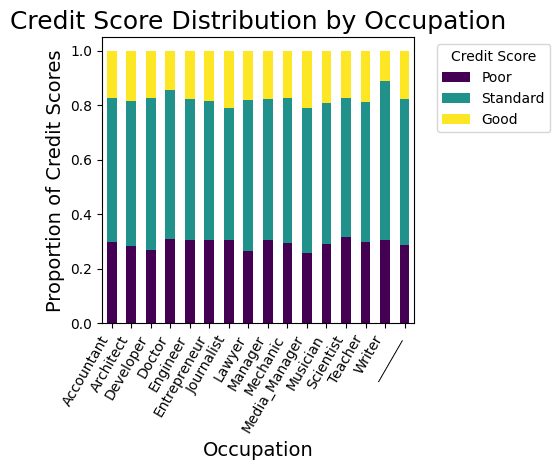

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for the stacked bar chart using the existing 'Occupation' column
occupation_credit_counts = df.groupby(['Occupation', 'Credit_Score']).size().unstack(fill_value=0)

# Calculate proportions for stacking
occupation_credit_proportions = occupation_credit_counts.apply(lambda x: x / x.sum(), axis=1)

# Define the order of Credit_Score categories for plotting
credit_score_order = ['Poor', 'Standard', 'Good']
# Reindex to ensure all credit_score_order columns exist, filling with 0 if not present
occupation_credit_proportions = occupation_credit_proportions.reindex(columns=credit_score_order, fill_value=0)

# Plotting the stacked bar chart
plt.figure(figsize=(16, 9)) # Increased figure size for better readability
occupation_credit_proportions.plot(kind='bar', stacked=True, cmap='viridis')
plt.title('Credit Score Distribution by Occupation', fontsize=18)
plt.xlabel('Occupation', fontsize=14)
plt.ylabel('Proportion of Credit Scores', fontsize=14)
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotate and adjust font size for x-axis labels
plt.yticks(fontsize=10)
plt.legend(title='Credit Score', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to prevent overlap
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()

In [41]:
x.drop(columns='Occupation',inplace=True)

In [42]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35795 entries, 0 to 36488
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  35795 non-null  object 
 1   Month                        35795 non-null  object 
 2   Age                          35795 non-null  int64  
 3   Annual_Income                35795 non-null  float64
 4   Monthly_Inhand_Salary        35795 non-null  float64
 5   Num_Bank_Accounts            35795 non-null  int64  
 6   Num_Credit_Card              35795 non-null  int64  
 7   Interest_Rate                35795 non-null  float64
 8   Num_of_Loan                  35795 non-null  int64  
 9   Delay_from_due_date          35795 non-null  int64  
 10  Num_of_Delayed_Payment       35795 non-null  float64
 11  Changed_Credit_Limit         35078 non-null  float64
 12  Num_Credit_Inquiries         35795 non-null  float64
 13  Credit_Mix           

In [43]:
x.select_dtypes(include=['object'])

,Customer_ID,Month,Credit_Mix,Credit_History_Age,Payment_of_Min_Amount,Payment_Behaviour
0,CUS_0xd40,January,_,22 Years and 1 Months,No,High_spent_Small_value_payments
1,CUS_0xd40,February,Good,NaN,No,Low_spent_Large_value_payments
2,CUS_0xd40,March,Good,22 Years and 3 Months,No,Low_spent_Medium_value_payments
3,CUS_0xd40,April,Good,22 Years and 4 Months,No,Low_spent_Small_value_payments
4,CUS_0xd40,May,Good,22 Years and 5 Months,No,High_spent_Medium_value_payments
...,...,...,...,...,...,...
36484,CUS_0x569b,May,Bad,10 Years and 6 Months,Yes,Low_spent_Small_value_payments
36485,CUS_0x569b,June,Bad,10 Years and 7 Months,NM,Low_spent_Small_value_payments
36486,CUS_0x569b,July,Bad,10 Years and 8 Months,Yes,Low_spent_Large_value_payments
36487,CUS_0x569b,August,Bad,10 Years and 9 Months,Yes,Low_spent_Small_value_payments


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35795 entries, 0 to 36488
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               35795 non-null  object 
 1   Month                     35795 non-null  object 
 2   Age                       35795 non-null  int64  
 3   Occupation                35795 non-null  object 
 4   Annual_Income             35795 non-null  object 
 5   Monthly_Inhand_Salary     35795 non-null  float64
 6   Num_Bank_Accounts         35795 non-null  int64  
 7   Num_Credit_Card           35795 non-null  int64  
 8   Interest_Rate             35795 non-null  float64
 9   Num_of_Loan               35795 non-null  int64  
 10  Type_of_Loan              35795 non-null  object 
 11  Delay_from_due_date       35795 non-null  int64  
 12  Num_of_Delayed_Payment    35795 non-null  float64
 13  Changed_Credit_Limit      35795 non-null  object 
 14  Num_Credit_

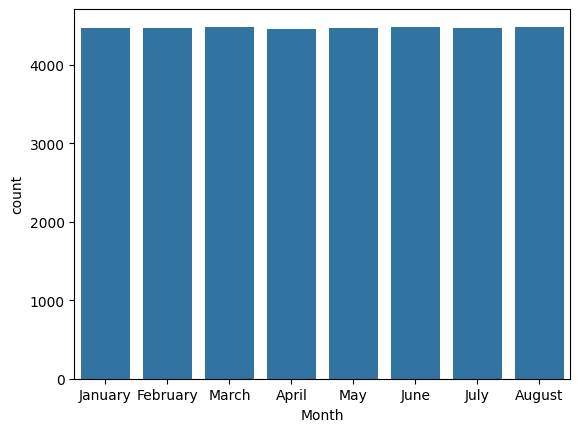

In [45]:
sns.countplot(x='Month', data=df)
plt.show()

In [46]:
x.drop(columns='Month',inplace=True)

In [47]:
print(f"Current shape of df: {df.shape}")

Current shape of df: (35795, 25)


In [48]:
x.select_dtypes(include=['object'])


,Customer_ID,Credit_Mix,Credit_History_Age,Payment_of_Min_Amount,Payment_Behaviour
0,CUS_0xd40,_,22 Years and 1 Months,No,High_spent_Small_value_payments
1,CUS_0xd40,Good,NaN,No,Low_spent_Large_value_payments
2,CUS_0xd40,Good,22 Years and 3 Months,No,Low_spent_Medium_value_payments
3,CUS_0xd40,Good,22 Years and 4 Months,No,Low_spent_Small_value_payments
4,CUS_0xd40,Good,22 Years and 5 Months,No,High_spent_Medium_value_payments
...,...,...,...,...,...
36484,CUS_0x569b,Bad,10 Years and 6 Months,Yes,Low_spent_Small_value_payments
36485,CUS_0x569b,Bad,10 Years and 7 Months,NM,Low_spent_Small_value_payments
36486,CUS_0x569b,Bad,10 Years and 8 Months,Yes,Low_spent_Large_value_payments
36487,CUS_0x569b,Bad,10 Years and 9 Months,Yes,Low_spent_Small_value_payments


In [49]:
df = df[df['Payment_Behaviour'] != '!@9#%8']

# Then split and encode cleanly
x['Spend_Level'] = x['Payment_Behaviour'].str.split('spent').str[0]
x['Payment_Size'] = x['Payment_Behaviour'].str.split('spent').str[1]\
                       .str.replace('_value_payments', '')

x.drop(columns=['Payment_Behaviour'], inplace=True)

x['Spend_Level']  = x['Spend_Level'].map({'Low': 0, 'High': 1})
x['Payment_Size'] = x['Payment_Size'].map({'Small': 0, 'Medium': 1, 'Large': 2})

In [50]:
# Define ordinal mappings
credit_mix_mapping = {'Bad': 0, '_': 1, 'Standard': 2, 'Good': 3}
payment_min_amount_mapping = {'No': 0, 'NM': 1, 'Yes': 2}

# Apply ordinal encoding
x['Credit_Mix'] = x['Credit_Mix'].map(credit_mix_mapping)
x['Payment_of_Min_Amount'] = x['Payment_of_Min_Amount'].map(payment_min_amount_mapping)

# Fill any NaNs that might have resulted from values not in the mapping (e.g., if there were other unexpected strings)
x['Credit_Mix'] = x['Credit_Mix'].fillna(x['Credit_Mix'].median())
x['Payment_of_Min_Amount'] = x['Payment_of_Min_Amount'].fillna(x['Payment_of_Min_Amount'].median())

display(x.head())

,Customer_ID,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,has_Personal_Loan,has_Payday_Loan,has_Credit-Builder_Loan,has_Student_Loan,has_Mortgage_Loan,has_Home_Equity_Loan,has_Debt_Consolidation_Loan,has_Auto_Loan,Spend_Level,Payment_Size
0,CUS_0xd40,23,19114.12,1824.843333,3,4,3.0,4,3,7.0,...,1,0,1,0,0,1,0,1,NaN,NaN
1,CUS_0xd40,23,19114.12,3141.445833,3,4,3.0,4,-1,14.0,...,1,0,1,0,0,1,0,1,NaN,NaN
2,CUS_0xd40,33,19114.12,3141.445833,3,4,3.0,4,3,7.0,...,1,0,1,0,0,1,0,1,NaN,NaN
3,CUS_0xd40,23,19114.12,3141.445833,3,4,3.0,4,5,4.0,...,1,0,1,0,0,1,0,1,NaN,NaN
4,CUS_0xd40,23,19114.12,1824.843333,3,4,3.0,4,6,14.0,...,1,0,1,0,0,1,0,1,NaN,NaN


In [51]:
#code to extract the temporal information from text
def parse_credit_history_age(age):
    try:
      years = int(str(age).split('Years')[0].strip())
      months = int(str(age).split('and')[1].split('Months')[0].strip())
      total_months = years * 12 + months
      return total_months
    except:
      return np.nan

x['Credit_History_Age_Months'] = x['Credit_History_Age'].apply(parse_credit_history_age)
median_credit_history_age = x['Credit_History_Age_Months'].median()
x['Credit_History_Age_Months'] = x['Credit_History_Age_Months'].fillna(median_credit_history_age)
x.drop(columns=['Credit_History_Age'], inplace=True)

display(x[['Credit_History_Age_Months']].head())

,Credit_History_Age_Months
0,265.0
1,221.0
2,267.0
3,268.0
4,269.0


In [52]:
x.drop(columns=['Customer_ID'], inplace=True)#unlikely to affect model

In [53]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35795 entries, 0 to 36488
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          35795 non-null  int64  
 1   Annual_Income                35795 non-null  float64
 2   Monthly_Inhand_Salary        35795 non-null  float64
 3   Num_Bank_Accounts            35795 non-null  int64  
 4   Num_Credit_Card              35795 non-null  int64  
 5   Interest_Rate                35795 non-null  float64
 6   Num_of_Loan                  35795 non-null  int64  
 7   Delay_from_due_date          35795 non-null  int64  
 8   Num_of_Delayed_Payment       35795 non-null  float64
 9   Changed_Credit_Limit         35078 non-null  float64
 10  Num_Credit_Inquiries         35795 non-null  float64
 11  Credit_Mix                   35795 non-null  int64  
 12  Outstanding_Debt             35795 non-null  float64
 13  Credit_Utilization_Ra

In [54]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x , y, test_size=0.25, random_state=42, stratify=y)

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize the Random Forest Classifier with reduced n_estimators and n_jobs=1 for memory efficiency
# This makes it less prone to memory issues or long runtimes.


In [58]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    random_state=42
)

In [59]:
rf_model.fit(x_train, y_train)
print("Random Forest model fitted successfully.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(x_test)

# Calculate and display performance metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("\nRandom Forest Model Performance on Test Set:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Print classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest model fitted successfully.

Random Forest Model Performance on Test Set:
Accuracy: 0.7313
Precision: 0.7337
Recall: 0.7313
F1-Score: 0.7320

Random Forest Classification Report:
              precision    recall  f1-score   support

        Good       0.62      0.68      0.64      1583
        Poor       0.75      0.71      0.73      2631
    Standard       0.76      0.76      0.76      4735

    accuracy                           0.73      8949
   macro avg       0.71      0.72      0.71      8949
weighted avg       0.73      0.73      0.73      8949



In [60]:
y_train_pred = rf_model.predict(x_train)
y_test_pred = y_pred_rf

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Accuracy on Training set: {train_acc:.4f}")
print(f"Accuracy on Test set: {test_acc:.4f}")

Accuracy on Training set: 0.7884
Accuracy on Test set: 0.7313


In [61]:


importances = rf_model.feature_importances_
feature_names = x_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)
print(feat_imp.head())

                feature  importance
12     Outstanding_Debt    0.177795
5         Interest_Rate    0.134118
11           Credit_Mix    0.123878
7   Delay_from_due_date    0.067957
4       Num_Credit_Card    0.061273


In [62]:
n_features = len(feat_imp)
n_drop = int(0.2 * n_features)

bottom_features = feat_imp.tail(n_drop)['feature'].tolist()

print("Features to drop:")
print(bottom_features)#drop unimportant features to improve model

Features to drop:
['has_Personal_Loan', 'has_Auto_Loan', 'has_Debt_Consolidation_Loan', 'Spend_Level', 'Payment_Size']


In [63]:
x_train_reduced = x_train.drop(columns=bottom_features)
x_test_reduced = x_test.drop(columns=bottom_features)

In [64]:
rf_model.fit(x_train_reduced, y_train)

y_pred_test = rf_model.predict(x_test_reduced)
y_pred_train = rf_model.predict(x_train_reduced)

from sklearn.metrics import accuracy_score
print("New Accuracy:test", accuracy_score(y_test, y_pred_test))
print("New Accuracy:train", accuracy_score(y_train, y_pred_train))

New Accuracy:test 0.7292434908928372
New Accuracy:train 0.7834314236757803


In [65]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)
model.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3555
[LightGBM] [Info] Number of data points in the train set: 26846, number of used features: 27
[LightGBM] [Info] Start training from score -1.731972
[LightGBM] [Info] Start training from score -1.224267
[LightGBM] [Info] Start training from score -0.636593


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
               random_state=42, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8)

In [66]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7804223935635266
Classification Report:
               precision    recall  f1-score   support

        Good       0.75      0.72      0.73      1583
        Poor       0.77      0.79      0.78      2631
    Standard       0.80      0.80      0.80      4735

    accuracy                           0.78      8949
   macro avg       0.77      0.77      0.77      8949
weighted avg       0.78      0.78      0.78      8949



In [67]:
from lightgbm import LGBMClassifier, early_stopping

model = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=5,
    reg_lambda=10,
    random_state=42
)

model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    eval_metric='multi_logloss',
    callbacks=[early_stopping(100, verbose=False)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3555
[LightGBM] [Info] Number of data points in the train set: 26846, number of used features: 27
[LightGBM] [Info] Start training from score -1.731972
[LightGBM] [Info] Start training from score -1.224267
[LightGBM] [Info] Start training from score -0.636593
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, n_estimators=2000,
               num_leaves=64, random_state=42, reg_alpha=5, reg_lambda=10,
               subsample=0.8)

In [68]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7841099564197117
Classification Report:
               precision    recall  f1-score   support

        Good       0.76      0.71      0.73      1583
        Poor       0.78      0.79      0.79      2631
    Standard       0.80      0.80      0.80      4735

    accuracy                           0.78      8949
   macro avg       0.78      0.77      0.77      8949
weighted avg       0.78      0.78      0.78      8949



In [69]:
from sklearn.metrics import classification_report, accuracy_score

y_train_pred_lgbm = model.predict(x_train)

print("LGBM Training Accuracy:", accuracy_score(y_train, y_train_pred_lgbm))
print("LGBM Training Classification Report:\n", classification_report(y_train, y_train_pred_lgbm))

LGBM Training Accuracy: 0.9573493257841019
LGBM Training Classification Report:
               precision    recall  f1-score   support

        Good       0.97      0.96      0.96      4750
        Poor       0.94      0.97      0.95      7892
    Standard       0.97      0.95      0.96     14204

    accuracy                           0.96     26846
   macro avg       0.96      0.96      0.96     26846
weighted avg       0.96      0.96      0.96     26846



In [70]:
model = LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=31,          # reduce
    max_depth=6,            # restrict depth
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=10,           # increase
    reg_lambda=20,          # increase
    min_child_samples=50,   # increase
    random_state=42
)

In [73]:
median_changed_credit_limit = x_train['Changed_Credit_Limit'].median()
x_train['Changed_Credit_Limit'] = x_train['Changed_Credit_Limit'].fillna(median_changed_credit_limit)
x_test['Changed_Credit_Limit'] = x_test['Changed_Credit_Limit'].fillna(median_changed_credit_limit)
print(f"Filled missing 'Changed_Credit_Limit' values with median: {median_changed_credit_limit}")
print(f"Missing values in 'Changed_Credit_Limit' (x_train): {x_train['Changed_Credit_Limit'].isna().sum()}")
print(f"Missing values in 'Changed_Credit_Limit' (x_test): {x_test['Changed_Credit_Limit'].isna().sum()}")

Filled missing 'Changed_Credit_Limit' values with median: 9.24
Missing values in 'Changed_Credit_Limit' (x_train): 0
Missing values in 'Changed_Credit_Limit' (x_test): 0
